In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

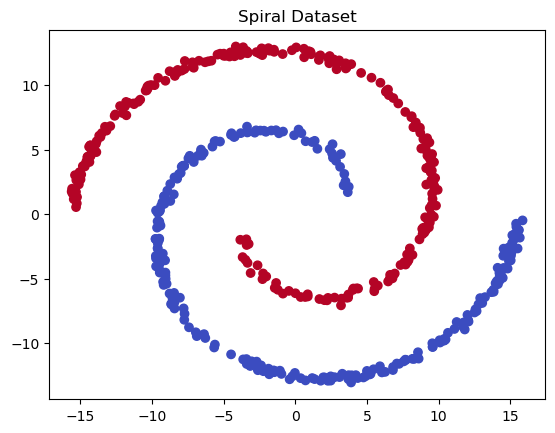

In [2]:
def generate_spiral(n_points=500, noise=0.2):
    np.random.seed(42)
    n = n_points // 2
    theta = np.sqrt(np.random.rand(n)) * 2 * np.pi

    r_a = 2*theta + np.pi
    data_a = np.array([np.cos(theta)*r_a, np.sin(theta)*r_a]).T

    r_b = -2*theta - np.pi
    data_b = np.array([np.cos(theta)*r_b, np.sin(theta)*r_b]).T

    X = np.vstack([data_a, data_b])
    X += np.random.randn(*X.shape) * noise

    y = np.array([0]*n + [1]*n)
    return X, y


X, y = generate_spiral()

plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm')
plt.title("Spiral Dataset")
plt.show()

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
def train_model(hidden_layers=(16,), activation='relu', lr=0.01):
    
    model = MLPClassifier(
        hidden_layer_sizes=hidden_layers,
        activation=activation,
        learning_rate_init=lr,
        max_iter=2000,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    
    return model, train_acc, test_acc

In [7]:
def plot_decision_boundary(model, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure()
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', edgecolors='k')
    plt.title(title)
    plt.show()

Depth 1 | Train: 1.000 | Test: 1.000


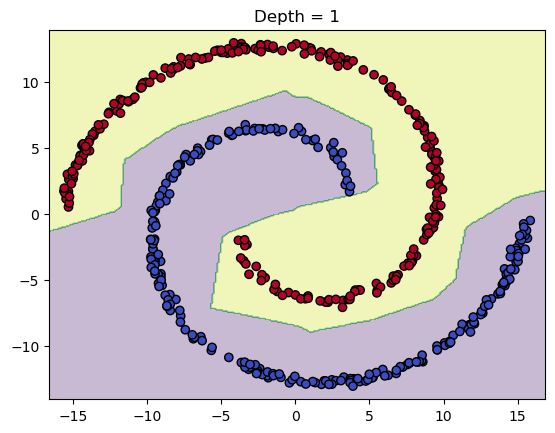

Depth 2 | Train: 1.000 | Test: 1.000


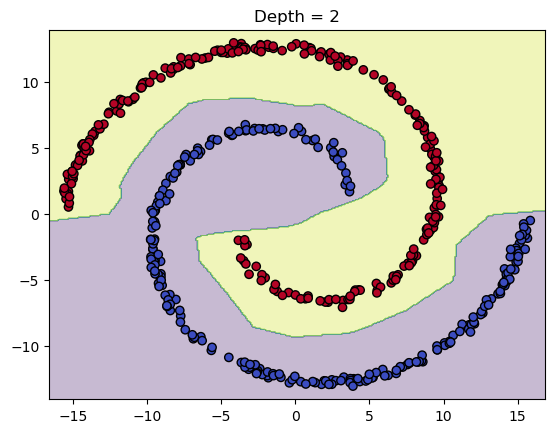

Depth 3 | Train: 1.000 | Test: 1.000


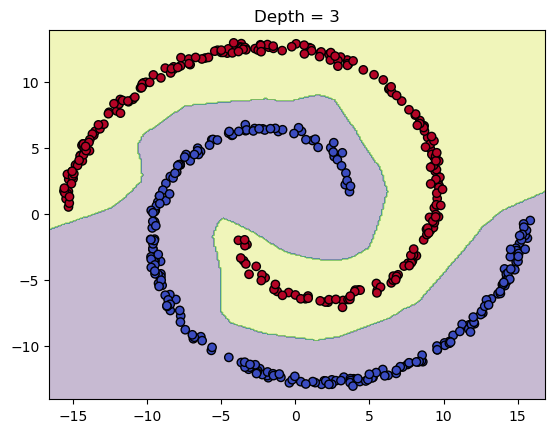

In [8]:
for d in [1,2,3]:
    model, train_acc, test_acc = train_model((16,)*d, 'relu')
    
    print(f"Depth {d} | Train: {train_acc:.3f} | Test: {test_acc:.3f}")
    plot_decision_boundary(model, f"Depth = {d}")

Width 4 | Train: 0.965 | Test: 0.960


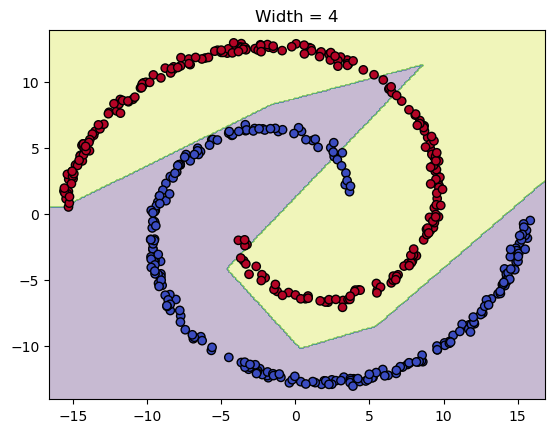

Width 16 | Train: 1.000 | Test: 1.000


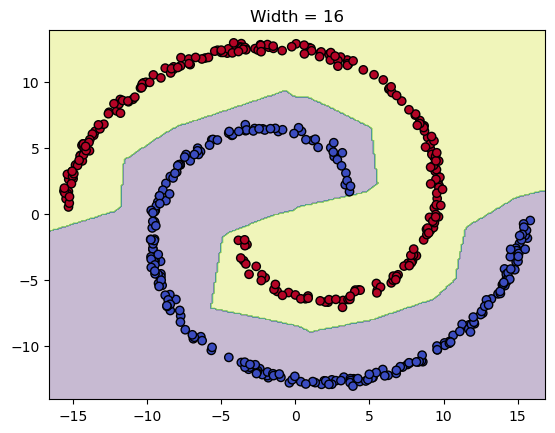

Width 64 | Train: 1.000 | Test: 1.000


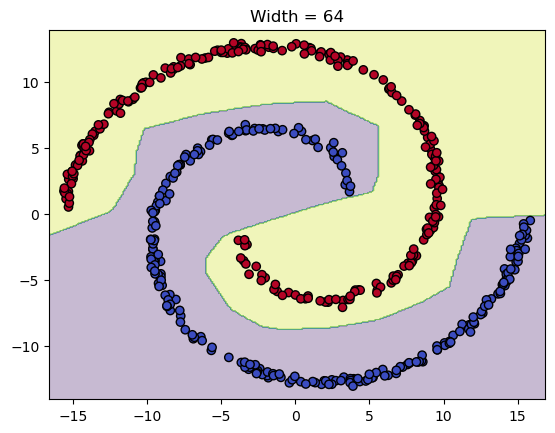

In [9]:
for w in [4,16,64]:
    model, train_acc, test_acc = train_model((w,), 'relu')
    
    print(f"Width {w} | Train: {train_acc:.3f} | Test: {test_acc:.3f}")
    plot_decision_boundary(model, f"Width = {w}")

logistic | Train: 0.995 | Test: 0.990


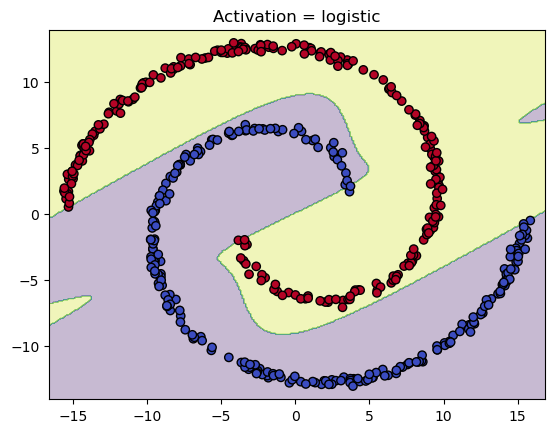

tanh | Train: 1.000 | Test: 1.000


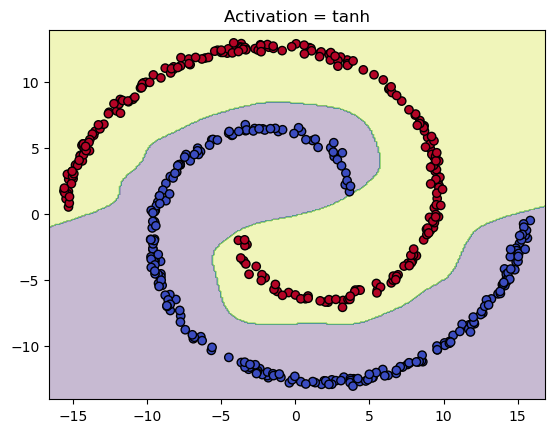

relu | Train: 1.000 | Test: 1.000


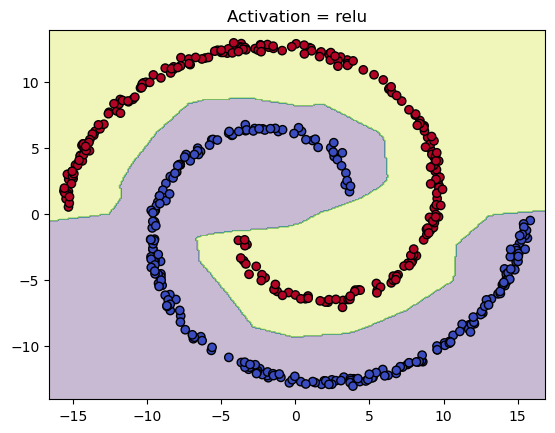

In [10]:
for act in ['logistic','tanh','relu']:
    model, train_acc, test_acc = train_model((16,16), act)
    
    print(f"{act} | Train: {train_acc:.3f} | Test: {test_acc:.3f}")
    plot_decision_boundary(model, f"Activation = {act}")

In [ ]:
model, train_acc, test_acc = train_model((128,128,128), 'relu')

print(f"Overfit | Train: {train_acc:.3f} | Test: {test_acc:.3f}")
plot_decision_boundary(model, "Overfitting Example")

Overfit | Train: 1.000 | Test: 1.000
